In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 10:45:55.326785


# Nuclear and whole cell 

* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/tutorials/outputs/xoa-output-understanding-outputs
* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/advanced/example-code
  

Go to "Transcript data"

"The transcripts file (transcripts.parquet) is provided in Parquet format to enable faster loading and reading of data (code examples here). It contains data to evaluate transcript quality and localization. The file contains one row for each decoded transcript"


Basically we need to subset on nuclear transcripts which are stored in the parquet file. So after creating the anndata split it into nuclear and whole-cell branches.

In [2]:
from pathlib import Path
import dask.dataframe as dd
import sys
import os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import anndata as ad
import matplotlib.pyplot as plt
import session_info

In [3]:
base_dir = Path("/home/workspace/projects/drg")

h5ad_dir     = base_dir / "data/h5ad/export_01/01_raw/output_folder"
xenium_root  = base_dir / "download/isolon" # for reading in matched parquets

whole_dir = base_dir / "data/h5ad/export_01/02a_raw/output_folder/whole"
nuc_dir   = base_dir / "data/h5ad/export_01/02b_raw/output_folder/nuclear_only"
fig_dir = base_dir / 'figures/qc/'
 

whole_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
nuc_dir.mkdir(parents=True, exist_ok=True)

In [4]:
def load_nuclear_matrix(parquet_path, genes, cells, min_qv=20):
    df = dd.read_parquet(parquet_path)
    # Keep only nuclear transcripts, high-quality, valid genes, assigned to valid cells
    nuc = df[
        (df["overlaps_nucleus"] == 1)
        & (df["qv"] >= min_qv)
        & (df["is_gene"])
        & (df["cell_id"].isin(cells))
    ].compute()

    # Build cell x gene matrix
    mat = nuc.groupby(["cell_id", "feature_name"]).size().unstack(fill_value=0)
    mat = mat.reindex(index=cells).fillna(0)
    mat = mat.reindex(columns=genes).fillna(0)
    return mat

In [5]:
summary_list = []

for fname in os.listdir(h5ad_dir):
    if not fname.endswith(".h5ad"):
        continue

    print(f"\nProcessing {fname} ...")

    # Load whole-cell h5ad
    adata = ad.read_h5ad(f"{h5ad_dir}/{fname}")

    # Find matching transcripts.parquet
    run_id = adata.obs["xenium_run_id"].iloc[0]
    parquet_path = f"{xenium_root}/{run_id}/transcripts.parquet"

    genes = adata.var_names
    cells = adata.obs_names

    # Compute nuclear counts
    nuc_df = load_nuclear_matrix(parquet_path, genes, cells)
    nuclear = nuc_df.to_numpy()

    # Add nuclear layer
    adata.layers["nuclear"] = nuclear

    # Compute nuclear fraction
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
    adata.obs["nuclear_fraction"] = nuclear.sum(1) / (X.sum(1) + 1e-9)

    # QC metrics 
    total_raw = X.sum(axis=1)
    total_nuc = nuclear.sum(axis=1)
    nuclear_fraction = total_nuc / (total_raw + 1e-9)
    mean_nuc_frac = np.mean(nuclear_fraction)
    mean_cyto_frac = 1 - mean_nuc_frac
    nuc_to_cyto_ratio = mean_nuc_frac / mean_cyto_frac

    rho_cell, _ = spearmanr(total_raw, total_nuc)
    gene_corrs = []
    for i in range(X.shape[1]):
        if X[:, i].sum() == 0:
            continue
        r, _ = spearmanr(X[:, i], nuclear[:, i])
        gene_corrs.append(r)
    mean_gene_corr = np.nanmean(gene_corrs)
    rho_global, _ = spearmanr(X.flatten(), nuclear.flatten())
    violations = np.sum(total_nuc > total_raw * 1.05)

    adata.uns["qc_summary"] = {
        "mean_nuclear_fraction": mean_nuc_frac,
        "mean_cytoplasmic_fraction": mean_cyto_frac,
        "nuc_to_cyto_ratio": nuc_to_cyto_ratio,
        "mean_cell_corr": rho_cell,
        "mean_gene_corr": mean_gene_corr,
        "global_corr": rho_global,
        "violations": int(violations),
        "total_nuclear_transcripts": int(total_nuc.sum()),
        "total_whole_transcripts": int(total_raw.sum())
    }

    # Save files
    adata.write(f"{whole_dir}/{fname.replace('.h5ad', '_whole.h5ad')}")

    adata_nuc = ad.AnnData(
        X=nuclear,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm.copy(),
        uns=adata.uns.copy(),
    )
    adata_nuc.write(f"{nuc_dir}/{fname.replace('.h5ad', '_nuclear.h5ad')}")

    print(f"Saved full-cell + nuclear layer: {whole_dir}/{fname.replace('.h5ad', '_whole.h5ad')}")
    print(f"Saved nuclear-only:              {nuc_dir}/{fname.replace('.h5ad', '_nuclear.h5ad')}")
    print(f"Spearman corr: {rho_cell:.3f}, mean fraction: {mean_nuc_frac:.3f}, violations: {violations}")

    summary_list.append({
        "sample": fname.replace(".h5ad", ""),
        "mean_nuclear_fraction": mean_nuc_frac,
        "mean_cytoplasmic_fraction": mean_cyto_frac,
        "nuc_to_cyto_ratio": nuc_to_cyto_ratio,
        "mean_cell_corr": rho_cell,
        "mean_gene_corr": mean_gene_corr,
        "global_corr": rho_global,
        "violations": int(violations),
        "total_nuclear_transcripts": int(total_nuc.sum()),
        "total_whole_transcripts": int(total_raw.sum())
    })

# Combined summary
summary_df = pd.DataFrame(summary_list)
print("\n=== Combined Summary Across Samples ===")
print(summary_df)

summary_path = whole_dir / "summary_nuclear_vs_cyto.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")


Processing TMA00311.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_01/02a_raw/output_folder/whole/TMA00311_whole.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_01/02b_raw/output_folder/nuclear_only/TMA00311_nuclear.h5ad
Spearman corr: 0.915, mean fraction: 0.581, violations: 0

Processing TMA00308.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_01/02a_raw/output_folder/whole/TMA00308_whole.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_01/02b_raw/output_folder/nuclear_only/TMA00308_nuclear.h5ad
Spearman corr: 0.937, mean fraction: 0.525, violations: 0

Processing TMA00307.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_01/02a_raw/output_folder/whole/TMA00307_whole.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_01/02b_raw/output_folder/nuclear_only/TMA00307_

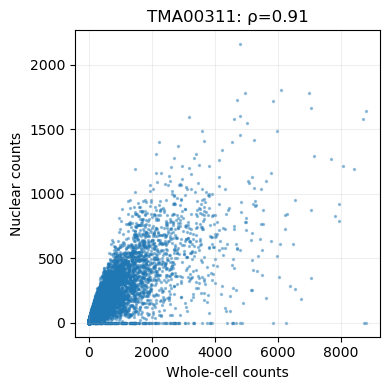

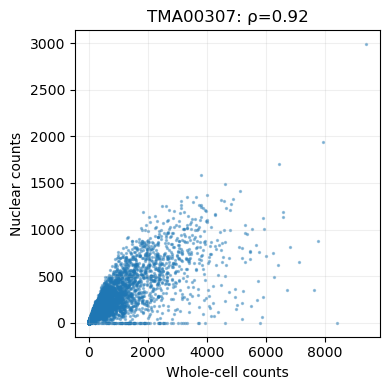

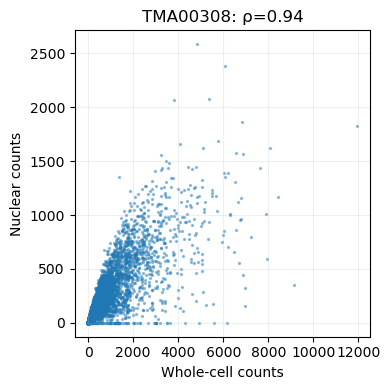

Saved scatter plots to /home/workspace/projects/drg/data/h5ad/export_01/02a_raw/output_folder/whole/qc_scatter_plots


In [6]:
plot_dir = os.path.join(whole_dir, "qc_scatter_plots")
os.makedirs(plot_dir, exist_ok=True)

for fname in os.listdir(whole_dir):
    if not fname.endswith(".h5ad"):
        continue
    
    path = os.path.join(whole_dir, fname)
    adata = ad.read_h5ad(path)
    sample_id = adata.obs["output_id"].iloc[0] if "output_id" in adata.obs else fname.replace(".h5ad", "")

    X_raw = adata.layers["raw"] if "raw" in adata.layers else adata.X
    X_nuc = adata.layers["nuclear"]
    X_raw = X_raw.toarray() if hasattr(X_raw, "toarray") else X_raw
    X_nuc = X_nuc.toarray() if hasattr(X_nuc, "toarray") else X_nuc

    total_raw = np.asarray(X_raw.sum(axis=1)).ravel()
    total_nuc = np.asarray(X_nuc.sum(axis=1)).ravel()
    rho, _ = spearmanr(total_raw, total_nuc)

    # Save figure per sample
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(total_raw, total_nuc, s=2, alpha=0.4)
    ax.set_xlabel("Whole-cell counts")
    ax.set_ylabel("Nuclear counts")
    ax.set_title(f"{sample_id}: ρ={rho:.2f}")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()

    #fig.savefig(os.path.join(plot_dir, f"{sample_id}_nuclear_vs_whole.png"), dpi=150)
    plt.show()

print(f"Saved scatter plots to {plot_dir}")

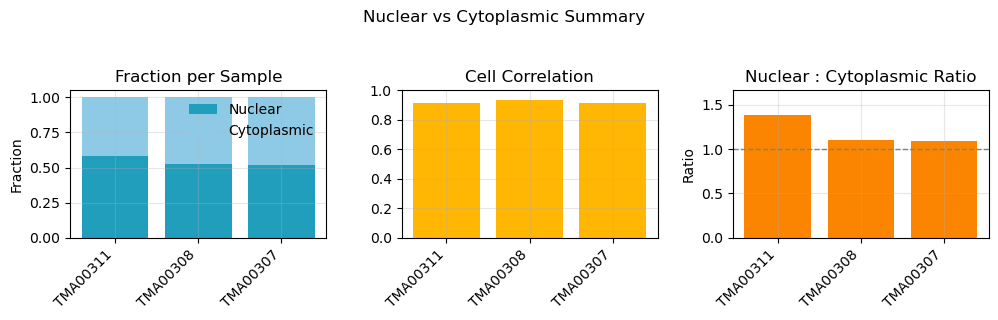

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# 1. Nuclear vs cytoplasmic fractions
axes[0].bar(summary_df["sample"], summary_df["mean_nuclear_fraction"], color="#219ebc", label="Nuclear")
axes[0].bar(summary_df["sample"], summary_df["mean_cytoplasmic_fraction"],
            bottom=summary_df["mean_nuclear_fraction"], color="#8ecae6", label="Cytoplasmic")
axes[0].set_title("Fraction per Sample")
axes[0].set_ylabel("Fraction")
axes[0].legend(frameon=False)

# 2. Spearman correlation
axes[1].bar(summary_df["sample"], summary_df["mean_cell_corr"], color="#ffb703")
axes[1].set_title("Cell Correlation")
axes[1].set_ylim(0, 1)

# 3. Nuclear : cytoplasmic ratio
axes[2].bar(summary_df["sample"], summary_df["nuc_to_cyto_ratio"], color="#fb8500")
axes[2].axhline(1, color="gray", ls="--", lw=1)
axes[2].set_title("Nuclear : Cytoplasmic Ratio")
axes[2].set_ylim(0, max(summary_df["nuc_to_cyto_ratio"]) * 1.2)
axes[2].set_ylabel("Ratio")

# Shared formatting
for ax in axes:
    ax.set_xticks(range(len(summary_df)))
    ax.set_xticklabels(summary_df["sample"], rotation=45, ha="right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Nuclear vs Cytoplasmic Summary", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

# Session info

In [8]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
